In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 108.9 kB/s eta 0:00:01
     ----------------------------- -------- 41.0/52.8 kB 178.6 kB/s eta 0:00:01
     ------------------------------------ - 51.2/52.8 kB 201.8 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 170.4 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ------------------------------ -------- 92.2/119.8 kB 2.6 MB/s eta 0:00:01
     -------------------------------------- 119.8/119.8 kB 1.7 MB/s eta 0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
df=pd.read_excel('weigth_height.xlsx')

Text(0, 0.5, 'height')

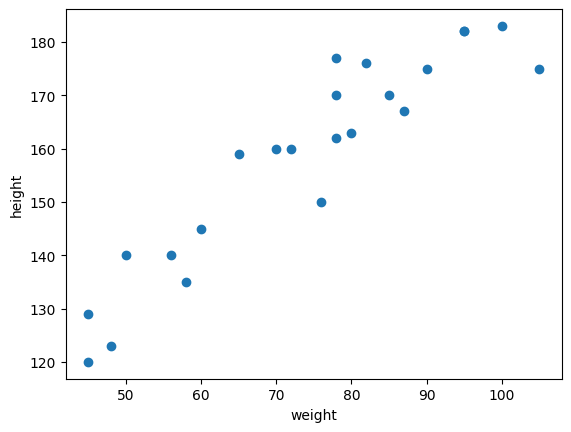

In [8]:
plt.scatter(df['weight'],df['height'])
plt.xlabel("weight")
plt.ylabel("height")

In [9]:
X=df[['weight']]
Y=df['height']

In [ ]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42)

In [17]:
X_train.shape

(18, 1)

In [ ]:
# standardization for doing same scaling
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)
X_train

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

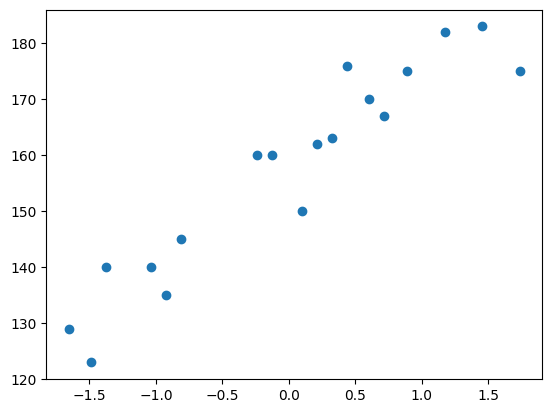

In [20]:
plt.scatter(X_train,Y_train)

In [ ]:
# train model with linear regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
regression.coef_

array([17.03440872])

In [27]:
regression.intercept_

np.float64(157.5)

In [28]:
y_pred=regression.predict(X_test)

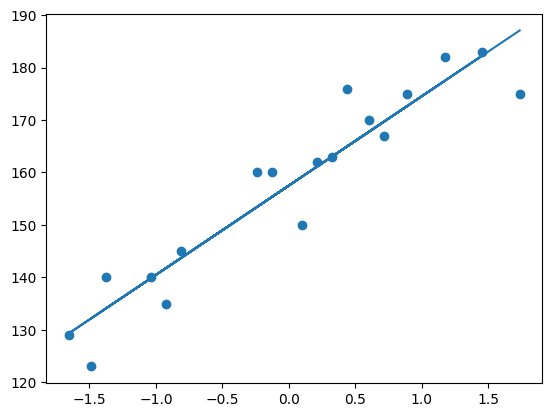

In [ ]:
# plot the training data for best fit line
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train))

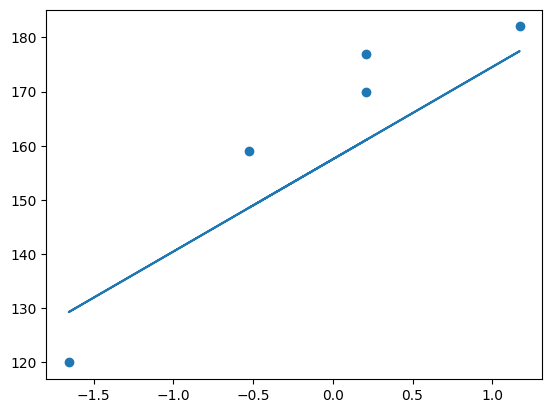

In [ ]:
# plot the test data for best fit line
plt.scatter(X_test,Y_test)
plt.plot(X_test,y_pred)

In [33]:
# performance matrices
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
mae=mean_absolute_error(Y_test,y_pred)
mse=mean_squared_error(Y_test,y_pred)
rmse=root_mean_squared_error(Y_test,y_pred)
score=r2_score(Y_test,y_pred)
print(mae,mse,rmse,score)

9.822657814519232 109.77592599051664 10.477400726827081 0.776986986042344


In [34]:
# adjusted r2_score
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.7026493147231252

In [37]:
# prediction for new data point
regression.predict(scale.transform([[80]]))

c:\Users\hp\Desktop\ml project\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([163.01076266])

In [38]:
regression.predict(scale.transform([[0]]))

c:\Users\hp\Desktop\ml project\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([85.96709053])

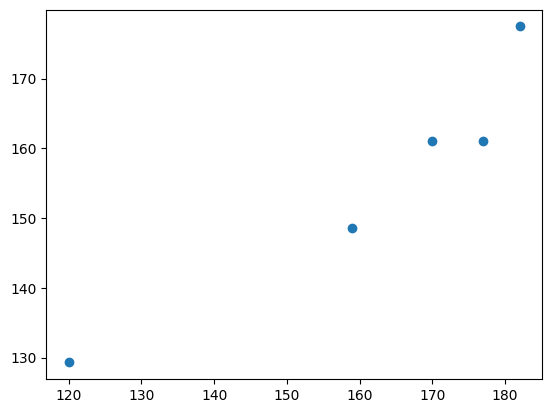

In [39]:
plt.scatter(Y_test,y_pred)

In [40]:
# residuals=y_test-y_pre
residuals=Y_test-y_pred
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: height, dtype: float64

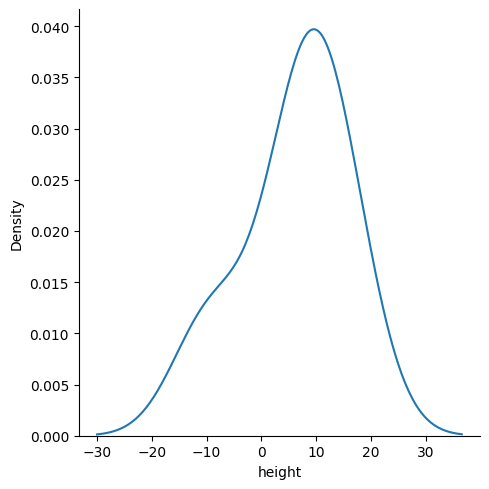

In [42]:
sns.displot(residuals,kind='kde')

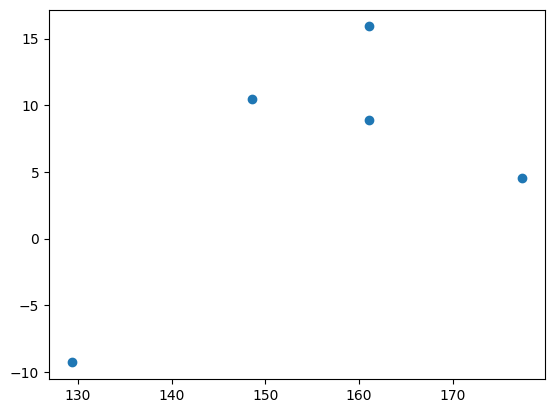

In [43]:
plt.scatter(y_pred,residuals)